In [ ]:
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

file_path_meta = '/content/drive/My Drive/ML_Project_Data/16k_Movies.csv'  # Replace with your actual file path
file_path_top = '/content/drive/My Drive/ML_Project_Data/Top Movies.csv'  # Replace with your actual file path

df_top_movies = pd.read_csv(file_path_top)
print(df_top_movies.head()) # Display first few rows to verify import

df_meta = pd.read_csv(file_path_meta,encoding='unicode_escape')







Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  id                               Movie Name Release Date  \
0  1     Star Wars Ep. VII: The Force Awakens   2015-12-16   
1  2                 Avatar: The Way of Water   2022-12-09   
2  3    Indiana Jones and the Dial of Destiny   2023-06-28   
3  4                        Avengers: Endgame   2019-04-23   
4  5  Mission: Impossible—The Final Reckoning   2025-05-21   

   Production Budget (USD)  Domestic Gross (USD)  Worldwide Gross (USD)  \
0                533200000             936662225             2056046835   
1                460000000             684075767             2315589775   
2                402300000             174480468              383963057   
3                400000000             858373000             2748242781   
4                400000000                     0                      0   

   Domestic Box Office (USD)  International Box

In [ ]:

import pandas as pd
df_top_movies['Year'] = df_top_movies['Release Date'].str[:4]
df_top_movies['Year'] = pd.to_numeric(df_top_movies['Year'], errors='coerce').astype('Int64')
df_top_movies

,id,Movie Name,Release Date,Production Budget (USD),Domestic Gross (USD),Worldwide Gross (USD),Domestic Box Office (USD),International Box Office (USD),Worldwide Box Office (USD),Est. Domestic DVD Sales (USD),...,Creative Type,Production/Financing Companies,Production Countries,Languages,Domestic Releases,International Releases,Theater counts,Domestic Share Percentage,Movie URL,Year
0,1,Star Wars Ep. VII: The Force Awakens,2015-12-16,533200000,936662225,2056046835,936662225.0,1.119385e+09,2.056047e+09,39601100.0,...,Science Fiction,"Lucasfilm,Bad Robot",United States,English,"December 18th, 2015 (IMAX) byWalt DisneyDecemb...","December 16th, 2015 (Wide) (Belgium)December 1...","4,134 opening theaters/4,134 max. theaters, 9....",45.6,https://www.the-numbers.com/movie/Star-Wars-Ep...,2015
1,2,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,684075767.0,1.631514e+09,2.315590e+09,7771432.0,...,Science Fiction,"Lightstorm Entertainment,20th Century Studios,...",United States,English,"December 16th, 2022 (Wide) by20th Century Stud...","December 9th, 2022 (Wide) (Finland)December 14...","4,202 opening theaters/4,340 max. theaters, 11...",29.5,https://www.the-numbers.com/movie/Avatar-The-W...,2022
2,3,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,174480468.0,2.094826e+08,3.839631e+08,NaN,...,Historical Fiction,"Lucasfilm,Walt Disney Pictures,Paramount Pictures",United States,English,"June 30th, 2023 (Wide) byWalt DisneyJune 30th,...","June 28th, 2023 (Wide) (Australia)June 28th, 2...","4,600 opening theaters/4,600 max. theaters, 4....",45.4,https://www.the-numbers.com/movie/Indiana-Jone...,2023
3,4,Avengers: Endgame,2019-04-23,400000000,858373000,2748242781,858373000.0,1.889870e+09,2.748243e+09,23961293.0,...,Super Hero,Marvel Studios,United States,English,"April 26th, 2019 (Wide) byWalt DisneyApril 26t...","April 23rd, 2019 (Limited) (China)April 24th, ...","4,662 opening theaters/4,662 max. theaters, 8....",31.2,https://www.the-numbers.com/movie/Avengers-End...,2019
4,5,Mission: Impossible—The Final Reckoning,2025-05-21,400000000,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.the-numbers.com/movie/Mission-Impo...,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6564,"6,565",Following,1999-04-02,6000,48482,240495,48482.0,1.920130e+05,2.404950e+05,NaN,...,Contemporary Fiction,NaN,United Kingdom,English,"April 2nd, 1999 (Wide) byZeitgeist","August 23rd, 2023 (Limited) (Italy)June 6th, 2...","1 opening theaters/2 max. theaters, 4.0 weeks ...",20.2,https://www.the-numbers.com/movie/Following#ta...,1999
6565,"6,566",Return to the Land of Wonders,2005-07-13,5000,1338,1338,1338.0,NaN,NaN,NaN,...,Factual,NaN,"Germany,United Kingdom,United States",NaN,"July 13th, 2005 (Limited) byArab Film Distribu...",NaN,"1 opening theaters/1 max. theaters, 2.0 weeks ...",100.0,https://www.the-numbers.com/movie/Return-to-th...,2005
6566,"6,567",A Plague So Pleasant,2015-09-29,1400,0,0,NaN,NaN,NaN,24343.0,...,Science Fiction,NaN,United States,English,NaN,NaN,NaN,NaN,https://www.the-numbers.com/movie/Plague-So-Pl...,2015
6567,"6,568",My Date With Drew,2005-08-05,1100,181041,181041,181041.0,NaN,NaN,NaN,...,Factual,NaN,United States,NaN,"August 5th, 2005 (Limited) byDEJ Productions",NaN,"58 opening theaters/58 max. theaters, 1.7 week...",100.0,https://www.the-numbers.com/movie/My-Date-With...,2005


In [ ]:
df_top_movies_clean = df_top_movies[['id','Movie Name','Year','Production Budget (USD)','Worldwide Gross (USD)','Opening Weekend (USD)']].dropna()
df_top_movies_clean_rated = pd.merge(df_meta,df_top_movies_clean , left_on=['Title'], right_on=['Movie Name'], how='inner').dropna()
df_top_movies_clean_rated

,Unnamed: 0,Title,Release Date,Description,Rating,No of Persons Voted,Directed by,Written by,Duration,Genres,id,Movie Name,Year,Production Budget (USD),Worldwide Gross (USD),Opening Weekend (USD)
0,5,The Godfather,"Mar 24, 1972",Francis Ford Coppola's epic features Marlon Br...,9.3,"4,102",Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola",2 h 55 m,"Crime,Drama","4,527",The Godfather,1972,7000000,270007394,302393.0
1,6,Boyhood,"Jul 11, 2014","Filmed over 12 years with the same cast, Richa...",7.5,"2,677",Richard Linklater,Richard Linklater,2 h 45 m,Drama,"5,106",Boyhood,2014,4000000,57273049,387618.0
6,28,Toy Story,"Nov 22, 1995","Led by Woody, Andy's toys live happily in his ...",8.8,"1,666",John Lasseter,"John Lasseter, Pete Docter, Andrew Stanton, Jo...",1 h 21 m,"Animation,Adventure,Comedy,Family,Fantasy","2,110",Toy Story,1995,30000000,365270951,29140617.0
7,30,12 Years a Slave,"Oct 18, 2013","In the pre-Civil War United States, Solomon No...",8.1,"1,694",Steve McQueen,"John Ridley, Solomon Northup",2 h 14 m,"Biography,Drama,History","2,866",12 Years a Slave,2013,20000000,180765061,923715.0
8,31,Manchester by the Sea,"Nov 18, 2016",After the death of his older brother Joe (Kyle...,8.2,"1,064",Kenneth Lonergan,Kenneth Lonergan,2 h 17 m,Drama,"4,350",Manchester by the Sea,2016,8500000,77733867,256498.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5369,16257,Meet the Spartans,"Jan 25, 2008","The heroic Leonidas, armed with nothing by lea...",4.2,202,"Jason Friedberg, \n \n Aaron Seltzer","Jason Friedberg, Aaron Seltzer",1 h 27 m,"Comedy,Fantasy","2,196",Meet the Spartans,2008,30000000,84646831,18505530.0
5370,16265,Baby Geniuses,"Mar 12, 1999",Two doctors (Turner and Lloyd) set out to domi...,3.1,55,Bob Clark,"Steven Paul, Francisca Matos, Robert Grasmere,...",1 h 37 m,"Comedy,Crime,Family,Sci-Fi","3,699",Baby Geniuses,1999,13000000,27151490,5613587.0
5371,16267,Miss March,"Mar 13, 2009",Miss March tells the story of a young man who ...,4.3,32,"Zach Cregger, \n \n Trevor Moore","Zach Cregger, Trevor Moore, Dennis Haggerty, R...",1 h 29 m,"Comedy,Romance","4,730",Miss March,2009,6000000,4713059,2409156.0
5372,16269,Screwed,"May 12, 2000","Working for a wealthy boss, a chauffeur kidnap...",7.9,80,"Scott Alexander, \n \n Larry Karaszewski","Scott Alexander, Larry Karaszewski",1 h 21 m,"Comedy,Crime","3,858",Screwed,2000,12000000,6982680,3342085.0


In [ ]:
all_genres = df_top_movies_clean_rated['Genres']
all_genres


,Genres
0,"Crime,Drama"
1,Drama
6,"Animation,Adventure,Comedy,Family,Fantasy"
7,"Biography,Drama,History"
8,Drama
...,...
5369,"Comedy,Fantasy"
5370,"Comedy,Crime,Family,Sci-Fi"
5371,"Comedy,Romance"
5372,"Comedy,Crime"


In [ ]:
all_genres = all_genres.str.split(',').explode()
all_genres = all_genres.reset_index(drop=True).drop_duplicates().dropna().reset_index(drop=True)
all_genres

,Genres
0,Crime
1,Drama
2,Animation
3,Adventure
4,Comedy
5,Family
6,Fantasy
7,Biography
8,History
9,Sci-Fi


In [ ]:


for index, row in df_top_movies_clean_rated.iterrows():
    genres_in_row = row['Genres']
    if isinstance(genres_in_row, str): # Check if genres_in_row is a string (not NaN)
      movie_genre = genres_in_row
      for genre in all_genres:
          if genre in movie_genre:
              df_top_movies_clean_rated.loc[index, genre] = 1 # Set to 1 instead of incrementing since we initialised with 0s.
          else:
              df_top_movies_clean_rated.loc[index, genre] = 0 # Set to 0 instead of incrementing since we initialised with 0s.

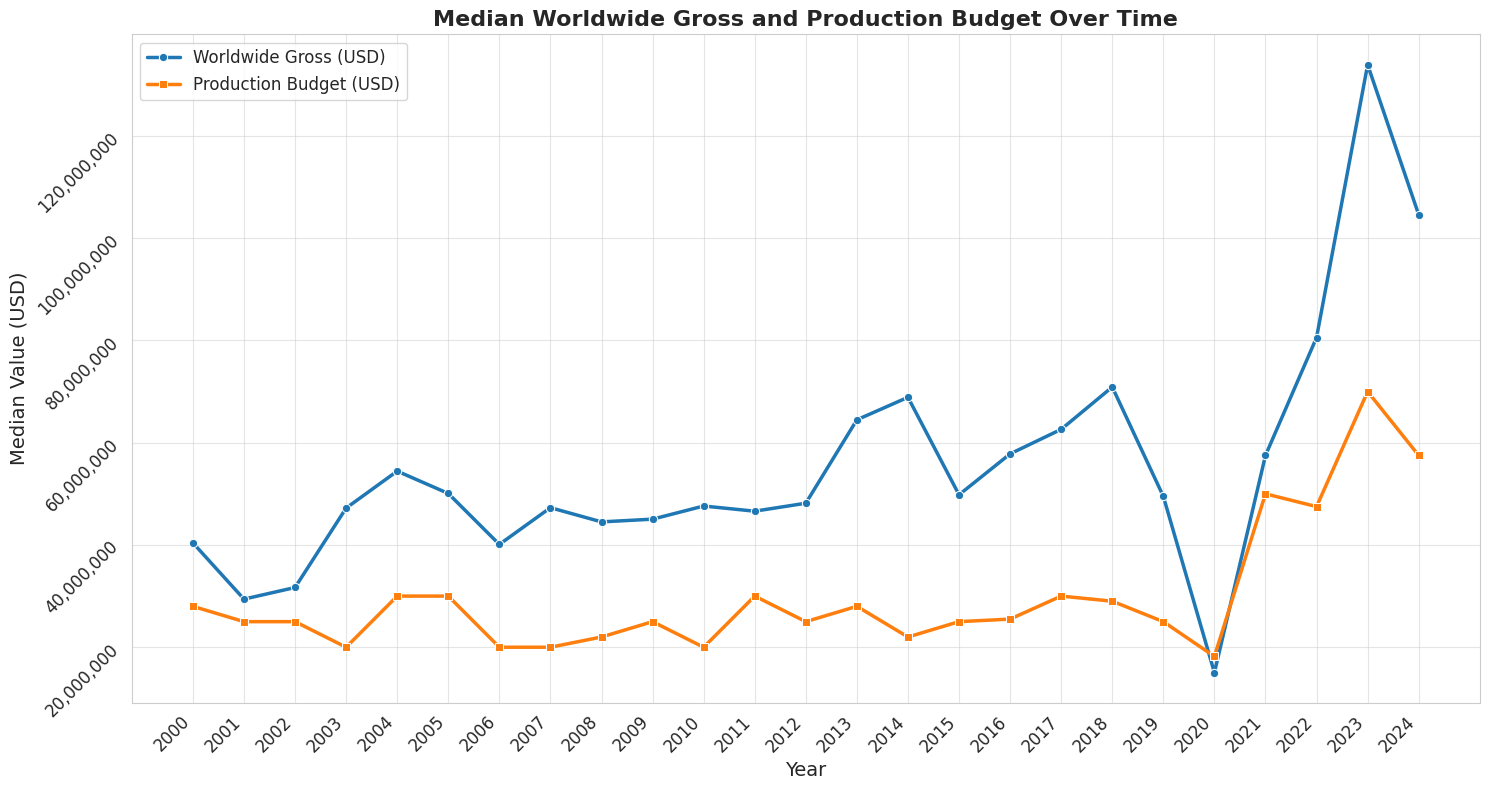

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

plt.rcParams['axes.formatter.useoffset'] = False

df_top_movies_clean_rated['Worldwide Gross (USD)'] = pd.to_numeric(df_top_movies_clean_rated['Worldwide Gross (USD)'], errors='coerce')
df_top_movies_clean_rated['Production Budget (USD)'] = pd.to_numeric(df_top_movies_clean_rated['Production Budget (USD)'], errors='coerce')


filtered_df = df_top_movies_clean_rated[
(df_top_movies_clean_rated['Year'] >= 2000)
]

average_values = filtered_df.groupby('Year')[['Worldwide Gross (USD)', 'Production Budget (USD)']].median()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

sns.lineplot(x=average_values.index, y=average_values['Worldwide Gross (USD)'], label='Worldwide Gross (USD)', marker='o', linewidth=2.5)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.gcf().axes[0].yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.lineplot(x=average_values.index, y=average_values['Production Budget (USD)'], label='Production Budget (USD)', marker='s', linewidth=2.5)
plt.title('Median Worldwide Gross and Production Budget Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Median Value (USD)', fontsize=14)
plt.xticks(average_values.index, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12,rotation=45, style = 'normal')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import multivariate_normal
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


scores = []
for i in range(15):


  My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)

  My_Movies_train = My_Movies_train.reset_index(drop=True)
  My_Movies_test = My_Movies_test.reset_index(drop=True)

  X = My_Movies_train[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)



  X_test = My_Movies_test[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y_test = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)


  reg = LinearRegression().fit(X, y)

  y_pred = reg.predict(X_test)


  diffs = abs(y_test-y_pred)
  scores.append(r2_score(y_test, y_pred))

print(sum(scores) / len(scores))

0.7936279663325673


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

scores = []
for i in range(15):

  My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)

  My_Movies_train = My_Movies_train.reset_index(drop=True)
  My_Movies_test = My_Movies_test.reset_index(drop=True)

  X = My_Movies_train[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)


  X_test = My_Movies_test[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y_test = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)




  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X)
  X_test_scaled = scaler.transform(X_test)

  ridge_cv = RidgeCV(alphas=[0.1, 0.5, 0.7,0.8, 1.0, 10.0], cv=15)
  ridge_cv.fit(X_train_scaled, y)

  y_pred = ridge_cv.predict(X_test_scaled)
  scores.append(r2_score(y_test, y_pred))

print(sum(scores) / len(scores))

0.784110365962308


In [ ]:
from sklearn.kernel_ridge import KernelRidge

import numpy as np

krr = KernelRidge(alpha=1.0)
krr.fit(X, y)

y_pred = krr.predict(X_test)
print("Model score (R^2):", r2_score(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Model score (R^2): 0.7234181406325696


In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)

My_Movies_train = My_Movies_train.reset_index(drop=True)
My_Movies_test = My_Movies_test.reset_index(drop=True)

X_l = My_Movies_train[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year']].reset_index(drop=True)
y_l = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)



X_test_l = My_Movies_test[['Production Budget (USD)','Opening Weekend (USD)','Rating','Year']].reset_index(drop=True)
y_test_l = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)

clf = linear_model.Lasso(alpha=0.00001)
clf.fit(X_l,y_l)

y_pred = clf.predict(X_test_l)
print("Model score (R^2):", r2_score(y_test_l, y_pred))

print(clf.coef_)

Model score (R^2): 0.7923054176373707
[ 1.08235780e+00  6.06633883e+00  1.09721271e+07 -8.03816719e+05]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.117e+19, tolerance: 1.811e+16
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Applying RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Displaying feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


                 Feature  Importance
0  Opening Weekend (USD)         1.0


<ipython-input-20-d611d3cd0ace>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis") # Use a visually appealing color palette


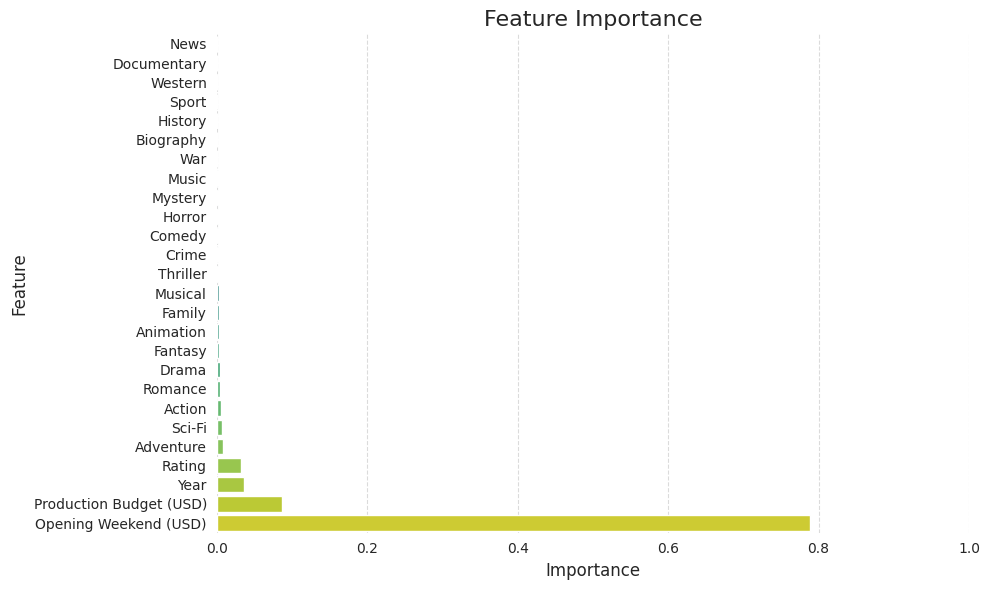

In [ ]:
# create bar chart from feature_importance and make it stylish

from sklearn.ensemble import RandomForestRegressor
# Applying RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Displaying feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'feature_importance' DataFrame is already created as in your provided code

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

# Create the bar plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis") # Use a visually appealing color palette

plt.title('Feature Importance', fontsize=16) # Add a title
plt.xlabel('Importance', fontsize=12)       # Label the x-axis
plt.ylabel('Feature', fontsize=12)         # Label the y-axis
plt.xticks(fontsize=10)                     # Adjust x-axis tick font size
plt.yticks(fontsize=10)                    # Adjust y-axis tick font size
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a subtle grid
sns.despine(left=True, bottom=True) # Remove the top and right spines for cleaner look

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [ ]:
from scipy.stats import multivariate_normal
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import math


scores = []
for i in range(15):

  My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)


  My_Movies_train = My_Movies_train.reset_index(drop=True)
  My_Movies_test = My_Movies_test.reset_index(drop=True)


  X = My_Movies_train[['Production Budget (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)


  X_test = My_Movies_test[['Production Budget (USD)','Rating','Year','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y_test = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)

  reg = LinearRegression().fit(X, y)

  y_pred = reg.predict(X_test)


  diffs = abs(y_test-y_pred)
  scores.append(r2_score(y_test, y_pred))

print(sum(scores) / len(scores))


0.5498986542773706


In [18]:
from scipy.stats import multivariate_normal
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

scores = []
for i in range(15):

  My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)

  My_Movies_train = My_Movies_train.reset_index(drop=True)
  My_Movies_test = My_Movies_test.reset_index(drop=True)


  X = My_Movies_train[['Opening Weekend (USD)','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)


  X_test = My_Movies_test[['Opening Weekend (USD)','Crime','Drama','Animation','Adventure','Comedy','Family','Fantasy','Biography','History','Sci-Fi','Thriller','Romance','Documentary','War','Action','Mystery','Music','Musical','Horror','Sport','Western','News']].reset_index(drop=True)
  y_test = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)

  reg = LinearRegression().fit(X, y)

  y_pred = reg.predict(X_test)


  diffs = abs(y_test-y_pred)

  scores.append(r2_score(y_test, y_pred))

print(sum(scores) / len(scores))


0.7649959820373601


In [ ]:
from scipy.stats import multivariate_normal
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

scores = []
for i in range(15):

  My_Movies_train, My_Movies_test = train_test_split(df_top_movies_clean_rated, test_size=0.2)

  My_Movies_train = My_Movies_train.reset_index(drop=True)
  My_Movies_test = My_Movies_test.reset_index(drop=True)

  X = My_Movies_train[['Opening Weekend (USD)']].reset_index(drop=True)
  y = My_Movies_train[['Worldwide Gross (USD)']].reset_index(drop=True)


  X_test = My_Movies_test[['Opening Weekend (USD)']].reset_index(drop=True)
  y_test = My_Movies_test[['Worldwide Gross (USD)']].reset_index(drop=True)

  reg = LinearRegression().fit(X, y)

  y_pred = reg.predict(X_test)


  diffs = abs(y_test-y_pred)
  scores.append(r2_score(y_test, y_pred))

print(sum(scores) / len(scores))


0.7526833900564293


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


                    Feature    Importance
0   Production Budget (USD)  6.346256e-01
1                    Rating  1.243138e-01
2                      Year  1.012583e-01
17                   Action  1.922796e-02
9                   Fantasy  1.406764e-02
12                   Sci-Fi  1.280984e-02
13                 Thriller  1.138210e-02
14                  Romance  1.118107e-02
5                 Animation  1.034844e-02
4                     Drama  8.726517e-03
6                 Adventure  8.398662e-03
8                    Family  8.236807e-03
7                    Comedy  6.584493e-03
18                  Mystery  6.017624e-03
3                     Crime  5.811636e-03
21                   Horror  3.463718e-03
19                    Music  2.882768e-03
20                  Musical  2.724780e-03
10                Biography  1.897794e-03
11                  History  1.860767e-03
16                      War  1.554853e-03
22                    Sport  1.502914e-03
23                  Western  9.870

<ipython-input-27-cfa45733a1c7>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis") # Use a visually appealing color palette


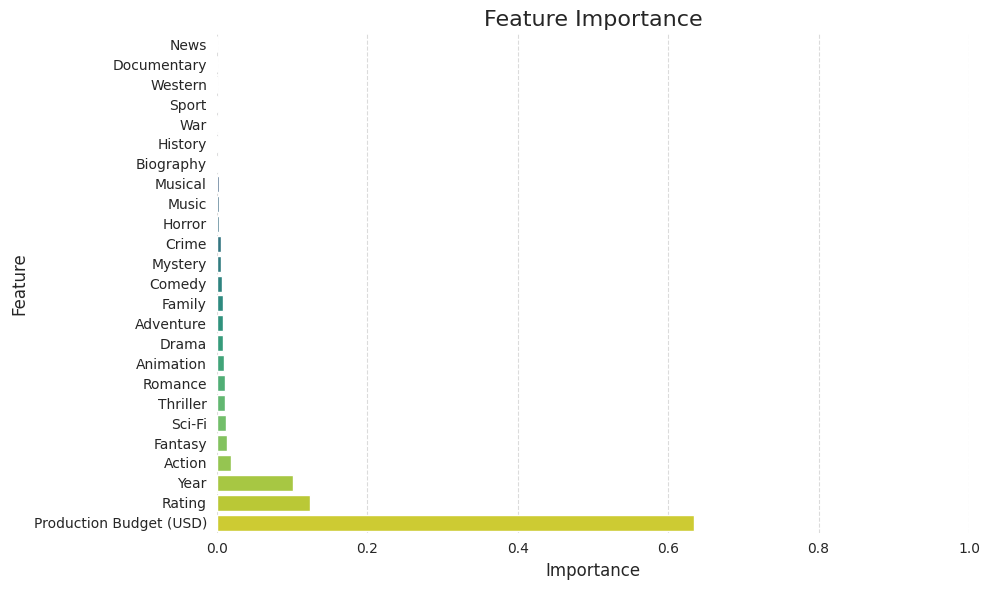

In [ ]:
# create bar chart from feature_importance and make it stylish

from sklearn.ensemble import RandomForestRegressor
# Applying RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Displaying feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'feature_importance' DataFrame is already created as in your provided code

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

# Create the bar plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="viridis") # Use a visually appealing color palette

plt.title('Feature Importance', fontsize=16) # Add a title
plt.xlabel('Importance', fontsize=12)       # Label the x-axis
plt.ylabel('Feature', fontsize=12)         # Label the y-axis
plt.xticks(fontsize=10)                     # Adjust x-axis tick font size
plt.yticks(fontsize=10)                    # Adjust y-axis tick font size
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add a subtle grid
sns.despine(left=True, bottom=True) # Remove the top and right spines for cleaner look

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
